In [169]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [170]:
directory_path = Path("final_clean_data")
files_list = [entry.name for entry in directory_path.iterdir() if entry.is_file()]

In [171]:
shapes = {}

In [172]:
temp_data = pd.read_csv(f'final_clean_data/{files_list[0]}', index_col=0)

In [173]:
for file in files_list:
    shapes[file[:-4]] = pd.read_csv(f'final_clean_data/{file}', index_col=0).shape[0]

In [174]:
shapes_df = pd.DataFrame(data=shapes.values(), index=shapes.keys(), columns=['shapes'])

In [175]:
stocks_to_take = list(shapes_df[(shapes_df['shapes'] >= 200) & (shapes_df.index != 'PATANJAL IN Equity')].index)
len(stocks_to_take)

238

In [176]:
total_data = {}
first_date = []
for stock in stocks_to_take:
    total_data[stock] = (pd.read_csv(f'final_clean_data/{stock}.csv', index_col=0)).iloc[-200:, :]
    first_date.append(total_data[stock].index[0])

In [177]:
first_date == [first_date[0] for i in range(len(first_date))]

True

In [178]:
index_to_take = None
for stock in stocks_to_take:
    total_data[stock].columns = [col+"_"+stock for col in total_data[stock].columns]
    index_to_take = list(total_data[stock].index)

In [179]:
full_df = pd.DataFrame(index=index_to_take)

In [180]:
for stock in stocks_to_take:
    full_df = pd.concat([full_df, total_data[stock]], axis=1)

In [181]:
np_full = np.array(full_df)

In [182]:
n_features = 6
n_stocks = np_full.shape[1]//n_features

data = np_full.reshape(200, n_stocks, n_features)

In [183]:
history = 12
X_data = []

for t in range(history, data.shape[0]):
    window = data[t-history:t, :, :]
    window = window.transpose(1, 0, 2)
    X_data.append(window)

In [184]:
price = data[:, :, 0]
price_ratio = price[1:]/price[:-1]
price_ratio_data = price_ratio[history:]

In [185]:
price

array([[  39.39,  108.14,   96.48, ...,  103.9 ,  471.8 ,  295.9 ],
       [  44.35,  106.06,   91.6 , ...,  103.35,  546.15,  315.65],
       [  37.99,   91.99,   88.68, ...,   83.9 ,  529.85,  280.3 ],
       ...,
       [ 753.55,  703.95,  379.35, ...,  290.15, 2878.  , 3230.3 ],
       [ 725.15,  637.4 ,  413.8 , ...,  317.95, 3117.8 , 3850.2 ],
       [ 727.55,  630.  ,  415.4 , ...,  308.4 , 3062.8 , 3824.9 ]],
      shape=(200, 238))

In [186]:
price_ratio_data.shape

(187, 238)

In [187]:
X_data[0].shape

(238, 12, 6)

In [188]:
len(X_data)

188

In [189]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import math

In [190]:
class stockLSTM(nn.Module):
    def __init__(self, num_features=6, hidden_size=6, history_window=12):
        super().__init__()
    
        self.num_features = num_features
        self.hidden_size = hidden_size
        self.history_window = history_window
    
        self.lstm = nn.LSTM(
            input_size = self.num_features,
            hidden_size = self.hidden_size,
            batch_first=True
        )

    def forward(self, x):
        """
        (n_stocks, history_window, n_features) -> (n_stocks, history_window, hidden_size)
        """
        if x.shape[1] != self.history_window:
            raise ValueError(
                f"Expected history_window = {self.history_window}, got {x.shape[1]}"
            )
            
        h_all, _ = self.lstm(x)
        return h_all
        
class historyAttention(nn.Module):
    def __init__(self, hidden_size = 6):
        super().__init__()

        self.W1 = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W2 = nn.Linear(hidden_size, hidden_size, bias=False)
        self.w = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, h_all):
        """
        (n_stocks, history_window, hidden_size) -> (n_stocks, hidden_size)
        """
        h_last = h_all[:, -1, :] # (n_stocks, hidden_size)
        W1h = self.W1(h_all) # (n_stocks, history_window, hidden_size)
        W2h = self.W2(h_last).unsqueeze(1) # (n_stocks, 1, hidden_size)

        alpha = self.w(torch.tanh(W1h + W2h)).squeeze(-1) # (n_stocks, history_window)
        att = torch.softmax(alpha, dim=1) # (n_stocks, history_window)
        r = torch.sum(att.unsqueeze(-1) * h_all, dim=1) # (n_stocks, hidden_size)

        return r


class crossAssetAttention(nn.Module):
    def __init__(self, hidden_size = 6):
        super().__init__()

        self.Wq = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Wk = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Wv = nn.Linear(hidden_size, hidden_size, bias=False)

        self.out = nn.Linear(hidden_size, 1)

    def forward(self, r):
        """
        (n_stocks, hidden_size) -> (n_stocks)
        """
        Q = self.Wq(r) # (n_stocks, hidden_size)
        K = self.Wk(r) # (n_stocks, hidden_size)
        V = self.Wv(r) # (n_stocks, hidden_size)

        scores = torch.matmul(Q, K.T) / math.sqrt(Q.shape[-1]) # (n_stocks, n_stocks)
        weights = torch.softmax(scores, dim=1) # (n_stocks, n_stocks)
        A = torch.matmul(weights, V) # (n_stocks, hidden_size)
        s = torch.sigmoid(self.out(A)).squeeze(-1) # (n_stocks)

        return s


def portfolio_generators(s, cutoff = 4):
    """
    (n_stocks) -> (n_stocks)
    """
    n = s.shape[0]
    G = n // cutoff

    order = torch.argsort(s, descending=True)
    top_idx = order[:G]
    bottom_idx = order[-G:]

    bc = torch.zeros_like(s)

    top_scores = s[top_idx]
    bc[top_idx] = torch.softmax(top_scores, dim=0)

    bottom_scores = 1 - s[bottom_idx]
    bc[bottom_idx] = -torch.softmax(bottom_scores, dim=0)

    return bc

model1 = stockLSTM()
model2 = historyAttention()
model3 = crossAssetAttention()


def alphastock_forward(X):
    h = model1(X)
    r = model2(h)
    s = model3(r)
    bc = portfolio_generators(s)
    return bc


def portfolio_return(bc, price_ratio):
    return torch.sum(bc * price_ratio)


def sharpe_ratio(returns):
    mean = returns.mean()
    std = returns.std()

    if std < 1e-6:
        return torch.tensor(0.0)

    return mean/std

def train_step(X_seq, price_ratio_seq, optimizer, market_sharpe):
    returns = []
    for t in range(len(X_seq)):
        bc = alphastock_forward(X_seq[t])
        r_t = portfolio_return(bc, price_ratio_seq[t])
        returns.append(r_t)

    returns = torch.stack(returns)
    H = sharpe_ratio(returns)
    loss = -(H - market_sharpe)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return H.item()


optimizer = torch.optim.Adam(
    list(model1.parameters()) +
    list(model2.parameters()) +
    list(model3.parameters()),
    lr=1e-3
)

In [191]:
X_data = [torch.tensor(x, dtype=torch.float32) for x in X_data]
price_ratio_data = [torch.tensor(z, dtype=torch.float32) for z in price_ratio_data]

In [192]:
traj_len = 12
test_start = len(X_data) - traj_len

train_X = X_data[:test_start]
train_z = price_ratio_data[:test_start]

test_X = X_data[test_start:]
test_z = price_ratio_data[test_start:]

In [ ]:
epochs = 500

for epoch in range(epochs):

    total_sharpe = 0
    count = 0

    for start in range(len(train_X) - traj_len):
        X_seq = train_X[start:start+traj_len]
        z_seq = train_z[start:start+traj_len]

        sharpe = train_step(X_seq, z_seq, optimizer, market_sharpe=0)
        total_sharpe+= sharpe
        count+=1

    print(f"epoch {epoch} train sharpe: {total_sharpe/count:.2f}")

epoch 0 train sharpe: 0.20
epoch 1 train sharpe: 0.21
epoch 2 train sharpe: 0.21
epoch 3 train sharpe: 0.21
epoch 4 train sharpe: 0.20
epoch 5 train sharpe: 0.20
epoch 6 train sharpe: 0.20
epoch 7 train sharpe: 0.21
epoch 8 train sharpe: 0.21
epoch 9 train sharpe: 0.21
epoch 10 train sharpe: 0.21
epoch 11 train sharpe: 0.21
epoch 12 train sharpe: 0.21
epoch 13 train sharpe: 0.21
epoch 14 train sharpe: 0.21
epoch 15 train sharpe: 0.21
epoch 16 train sharpe: 0.21
epoch 17 train sharpe: 0.22
epoch 18 train sharpe: 0.22
epoch 19 train sharpe: 0.22
epoch 20 train sharpe: 0.22
epoch 21 train sharpe: 0.28
epoch 22 train sharpe: 0.28
epoch 23 train sharpe: 0.27
epoch 24 train sharpe: 0.23
epoch 25 train sharpe: 0.19
epoch 26 train sharpe: 0.10


In [220]:
returns = []
for t in range(len(train_X)):
    bc = alphastock_forward(train_X[t])
    r = portfolio_return(bc, train_z[t])
    returns.append(r)

In [221]:
returns = np.array([val.item() for val in returns])

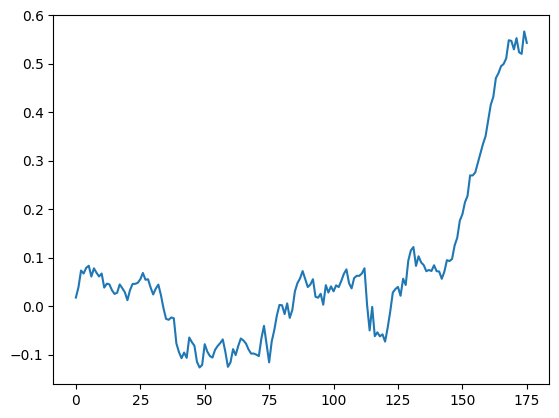

In [222]:
plt.plot(returns.cumsum())


In [219]:
returns

array([ 0.01827818,  0.00024615, -0.00807786,  0.00923859,  0.01390898,
       -0.0175007 , -0.0218365 ,  0.01802887,  0.01335471,  0.02614985,
       -0.00291109])